# Guard vs No-Guard Feature Analysis (A1/A2/A3)

This notebook builds publication-ready tables and plots for guard_full vs guard_no_guard using features A1/A2/A3 from the existing results summaries.

In [1]:

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- style (journal-like) ----
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BASE_DIR = Path("results")
OUT_DIR = Path("results/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "wikipedia_september_2007": "Wikipedia Sep 2007",
    "wiki2018": "Wiki2018",
}

FEATURES = ["A1", "A2", "A3"]
MODELS = {
    "guard_full": "Guard (full)",
    "guard_no_guard": "No guard",
}

LEARNER = "NB"  # change if you run SVM/DT summaries

def _summary_path(dataset, feature, model):
    fname = f"001_summary_ilnse_{feature}_{model}_{LEARNER}_all_sizes.json"
    return BASE_DIR / dataset / fname

def load_summary(dataset, feature, model):
    path = _summary_path(dataset, feature, model)
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

# Build dataframes
avg_rows = []
curve_rows = []
for ds in DATASETS:
    for model in MODELS:
        for feat in FEATURES:
            d = load_summary(ds, feat, model)
            avg_rows.append({
                "dataset": ds,
                "dataset_label": DATASETS[ds],
                "model": model,
                "model_label": MODELS[model],
                "feature": feat,
                "avg_hr": d["avg_hr"],
            })
            for row in d["hr_curve"]:
                curve_rows.append({
                    "dataset": ds,
                    "dataset_label": DATASETS[ds],
                    "model": model,
                    "model_label": MODELS[model],
                    "feature": feat,
                    "cache_size_objects": row["cache_size_objects"],
                    "hit_ratio": row["hit_ratio"],
                })

avg_df = pd.DataFrame(avg_rows)
curve_df = pd.DataFrame(curve_rows)

avg_df.head()


,dataset,dataset_label,model,model_label,feature,avg_hr
0,wikipedia_september_2007,Wikipedia Sep 2007,guard_full,Guard (full),A1,0.668685
1,wikipedia_september_2007,Wikipedia Sep 2007,guard_full,Guard (full),A2,0.676448
2,wikipedia_september_2007,Wikipedia Sep 2007,guard_full,Guard (full),A3,0.670011
3,wikipedia_september_2007,Wikipedia Sep 2007,guard_no_guard,No guard,A1,0.660884
4,wikipedia_september_2007,Wikipedia Sep 2007,guard_no_guard,No guard,A2,0.669959


## Table 1 — Average HR by feature (A1/A2/A3)

In [2]:

avg_table = avg_df.pivot_table(
    index=["dataset_label", "model_label"],
    columns="feature",
    values="avg_hr",
).sort_index()

avg_table


feature                                A1        A2        A3
dataset_label      model_label                               
Wiki2018           Guard (full)  0.522605  0.537505  0.522535
                   No guard      0.503842  0.527302  0.497677
Wikipedia Sep 2007 Guard (full)  0.668685  0.676448  0.670011
                   No guard      0.660884  0.669959  0.653384

In [3]:

# LaTeX export (booktabs)
latex_avg = avg_table.to_latex(
    float_format=lambda x: f"{x:.4f}",
    caption="Average hit ratio (HR) by feature set.",
    label="tab:avg_hr_features",
    bold_rows=False,
)
print(latex_avg)


\begin{table}
\centering
\caption{Average hit ratio (HR) by feature set.}
\label{tab:avg_hr_features}
\begin{tabular}{llrrr}
\toprule
                   & feature &     A1 &     A2 &     A3 \\
dataset\_label & model\_label &        &        &        \\
\midrule
Wiki2018 & Guard (full) & 0.5226 & 0.5375 & 0.5225 \\
                   & No guard & 0.5038 & 0.5273 & 0.4977 \\
Wikipedia Sep 2007 & Guard (full) & 0.6687 & 0.6764 & 0.6700 \\
                   & No guard & 0.6609 & 0.6700 & 0.6534 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_3984/641966774.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_avg = avg_table.to_latex(


## Table 2 — Guard benefit (avg HR gain)

In [4]:

guard_full = avg_df[avg_df["model"] == "guard_full"]
guard_none = avg_df[avg_df["model"] == "guard_no_guard"]

guard_delta = guard_full.merge(
    guard_none,
    on=["dataset", "dataset_label", "feature"],
    suffixes=("_full", "_no"),
)
guard_delta["avg_hr_gain"] = guard_delta["avg_hr_full"] - guard_delta["avg_hr_no"]

delta_table = guard_delta.pivot_table(
    index=["dataset_label"],
    columns="feature",
    values="avg_hr_gain",
)
delta_table


feature,A1,A2,A3
dataset_label,,,
Wiki2018,0.018763,0.010203,0.024859
Wikipedia Sep 2007,0.007801,0.006489,0.016627


In [5]:

latex_delta = delta_table.to_latex(
    float_format=lambda x: f"{x:+.4f}",
    caption="Average HR gain from guardrails (guard\_full - guard\_no\_guard).",
    label="tab:guard_gain",
    bold_rows=False,
)
print(latex_delta)


\begin{table}
\centering
\caption{Average HR gain from guardrails (guard\_full - guard\_no\_guard).}
\label{tab:guard_gain}
\begin{tabular}{lrrr}
\toprule
feature &      A1 &      A2 &      A3 \\
dataset\_label      &         &         &         \\
\midrule
Wiki2018           & +0.0188 & +0.0102 & +0.0249 \\
Wikipedia Sep 2007 & +0.0078 & +0.0065 & +0.0166 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_3984/3072958802.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_delta = delta_table.to_latex(


## Figure 1 — HR vs Cache Size (Guard Full)

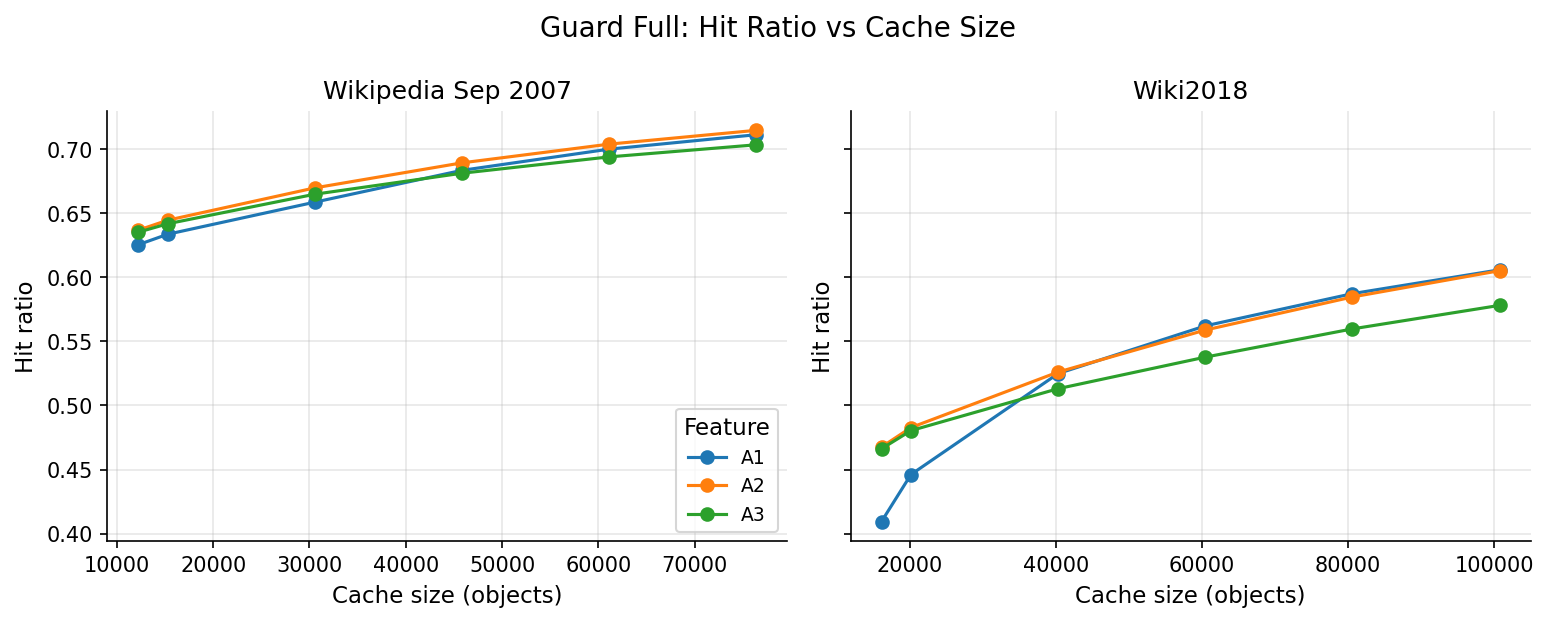

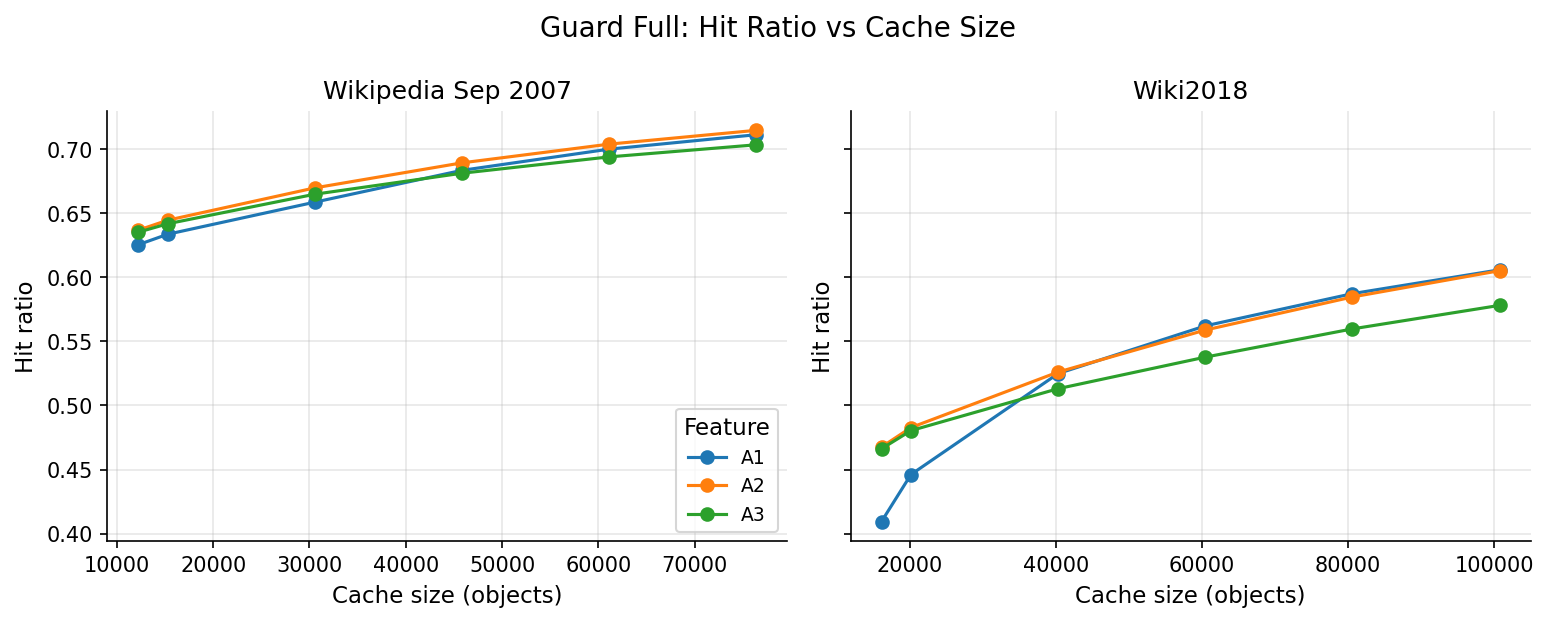

In [6]:

colors = {"A1": "#1f77b4", "A2": "#ff7f0e", "A3": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, (ds, ds_label) in zip(axes, DATASETS.items()):
    sub = curve_df[(curve_df["dataset"] == ds) & (curve_df["model"] == "guard_full")]
    for feat in FEATURES:
        s = sub[sub["feature"] == feat].sort_values("cache_size_objects")
        ax.plot(s["cache_size_objects"], s["hit_ratio"], marker="o", lw=1.5, color=colors[feat], label=feat)
    ax.set_title(ds_label)
    ax.set_xlabel("Cache size (objects)")
    ax.set_ylabel("Hit ratio")
axes[0].legend(title="Feature", loc="lower right")
fig.suptitle("Guard Full: Hit Ratio vs Cache Size")
fig.tight_layout()

fig_path = OUT_DIR / "guard_full_hr_curve.png"
fig.savefig(fig_path)
fig


## Figure 2 — HR vs Cache Size (No Guard)

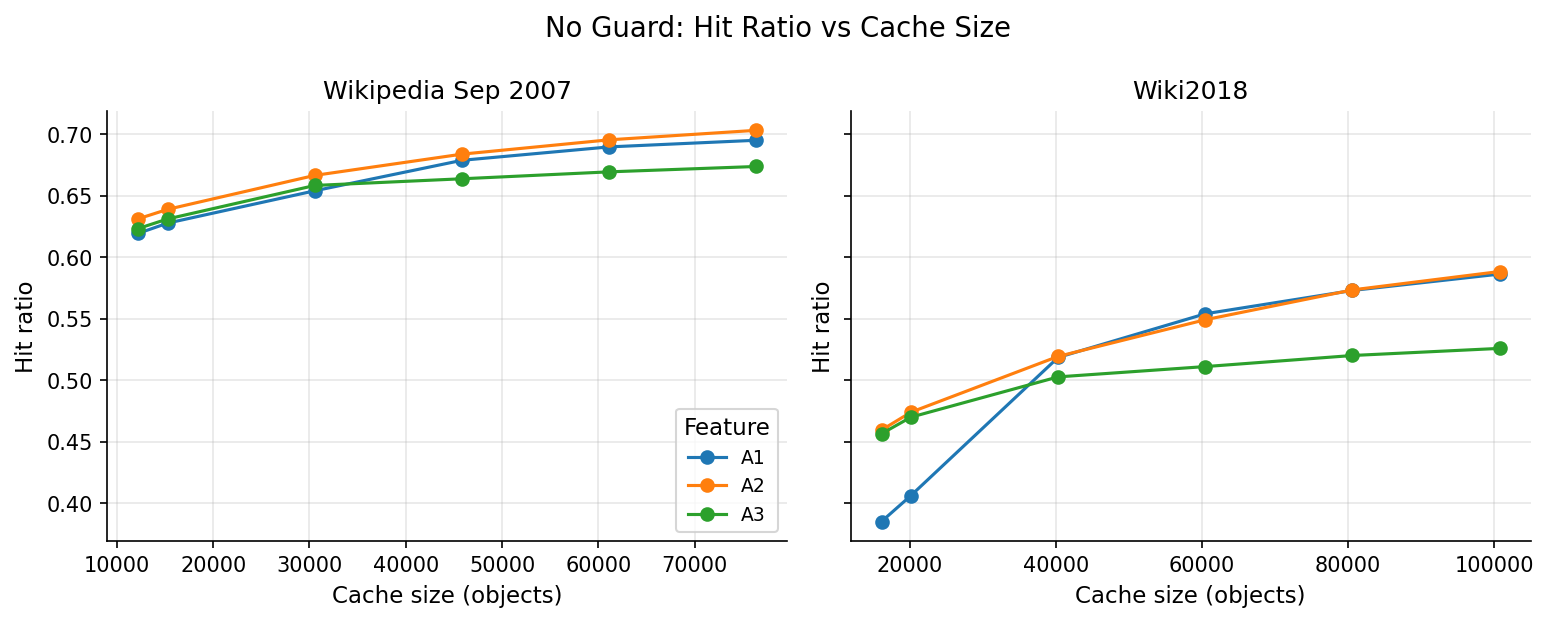

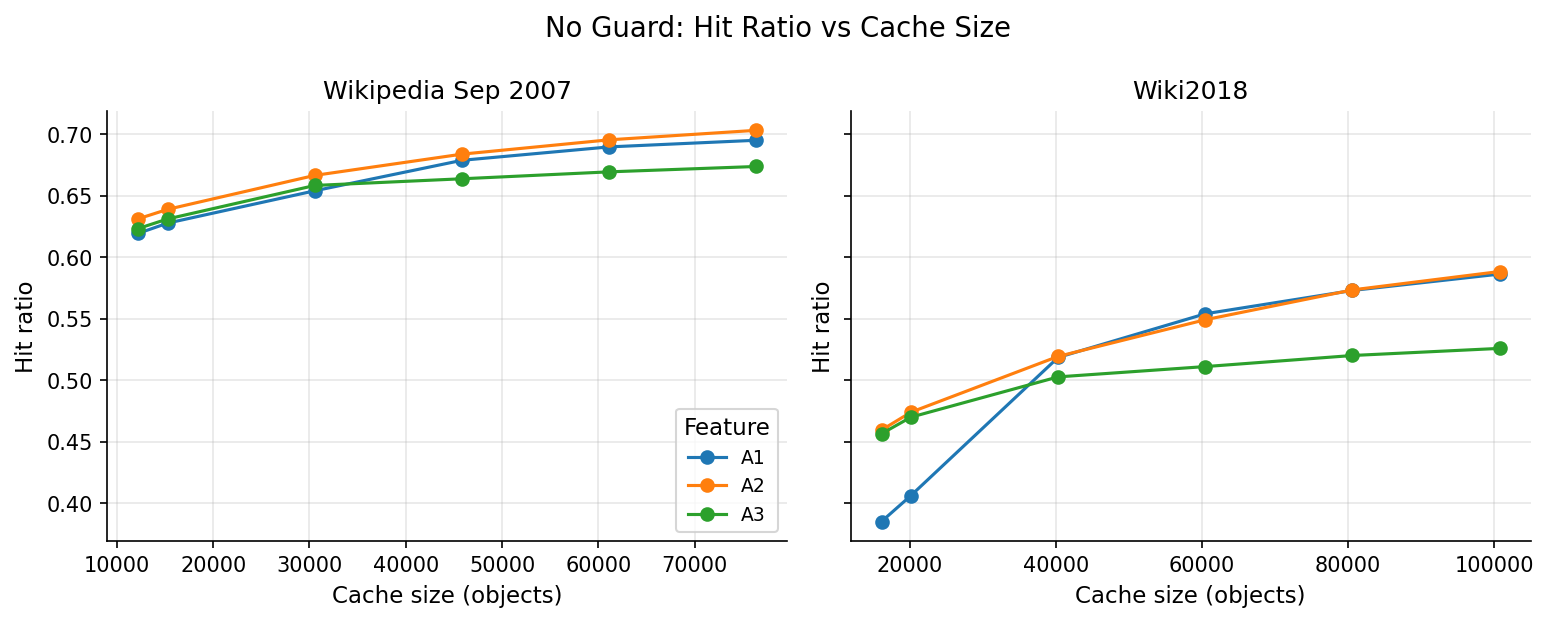

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, (ds, ds_label) in zip(axes, DATASETS.items()):
    sub = curve_df[(curve_df["dataset"] == ds) & (curve_df["model"] == "guard_no_guard")]
    for feat in FEATURES:
        s = sub[sub["feature"] == feat].sort_values("cache_size_objects")
        ax.plot(s["cache_size_objects"], s["hit_ratio"], marker="o", lw=1.5, color=colors[feat], label=feat)
    ax.set_title(ds_label)
    ax.set_xlabel("Cache size (objects)")
    ax.set_ylabel("Hit ratio")
axes[0].legend(title="Feature", loc="lower right")
fig.suptitle("No Guard: Hit Ratio vs Cache Size")
fig.tight_layout()

fig_path = OUT_DIR / "guard_no_guard_hr_curve.png"
fig.savefig(fig_path)
fig


## Figure 3 — Average HR by Feature (bar)

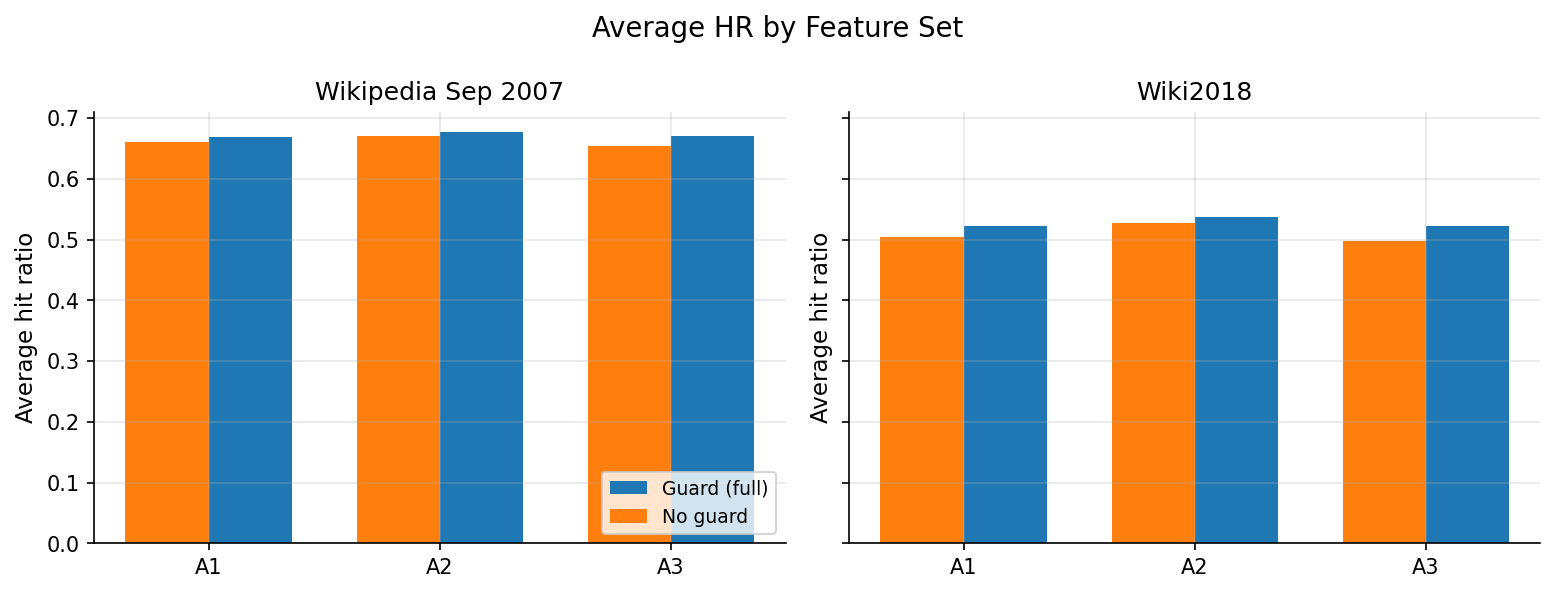

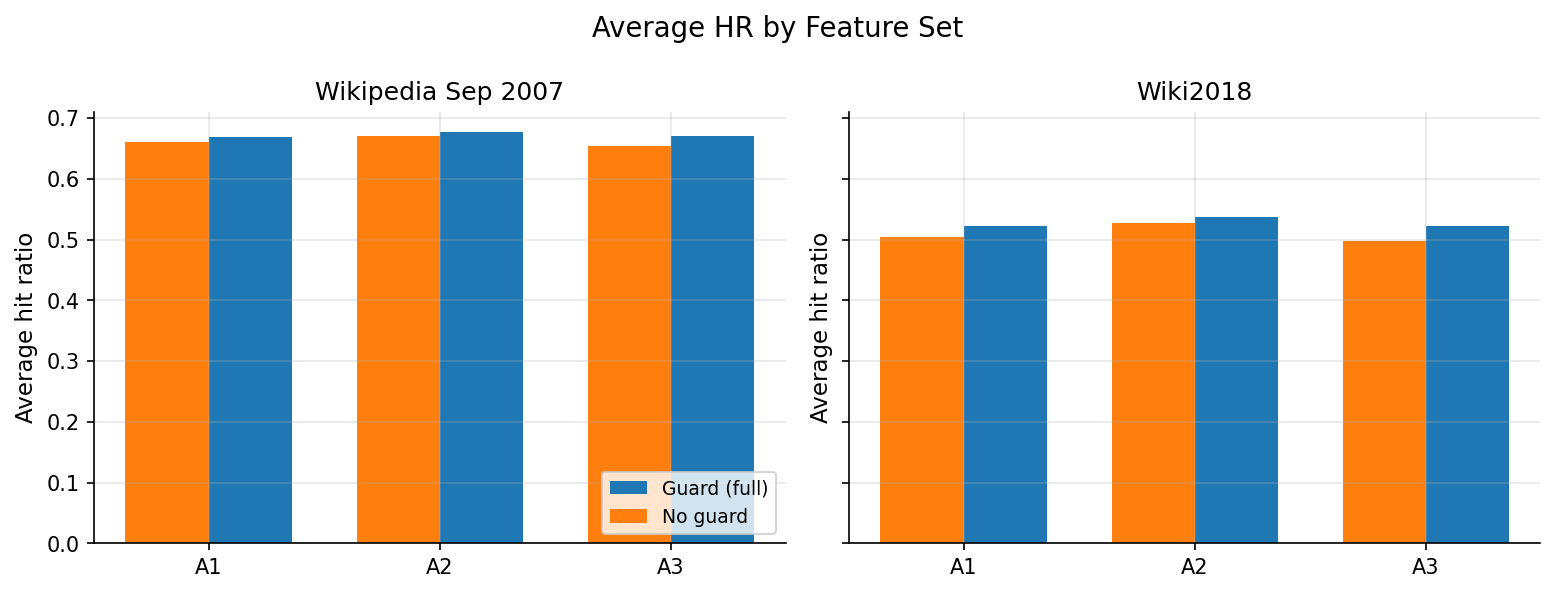

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
for ax, (ds, ds_label) in zip(axes, DATASETS.items()):
    sub = avg_df[avg_df["dataset"] == ds]
    for model, model_label in MODELS.items():
        s = sub[sub["model"] == model].set_index("feature").loc[FEATURES]
        x = np.arange(len(FEATURES)) + (0.18 if model == "guard_full" else -0.18)
        ax.bar(x, s["avg_hr"], width=0.36, label=model_label)
    ax.set_xticks(np.arange(len(FEATURES)))
    ax.set_xticklabels(FEATURES)
    ax.set_title(ds_label)
    ax.set_ylabel("Average hit ratio")
axes[0].legend(loc="lower right")
fig.suptitle("Average HR by Feature Set")
fig.tight_layout()

fig_path = OUT_DIR / "avg_hr_bar.png"
fig.savefig(fig_path)
fig


## Figure 4 — Guard Gain by Feature (bar)

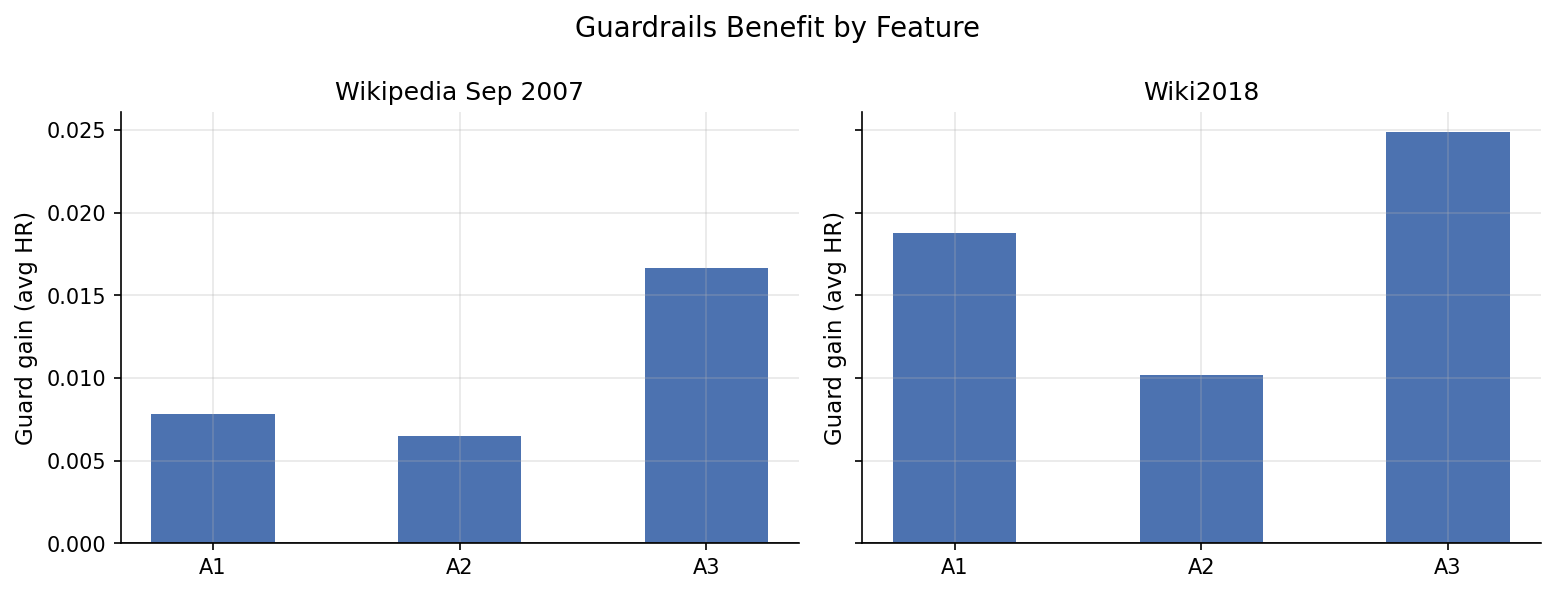

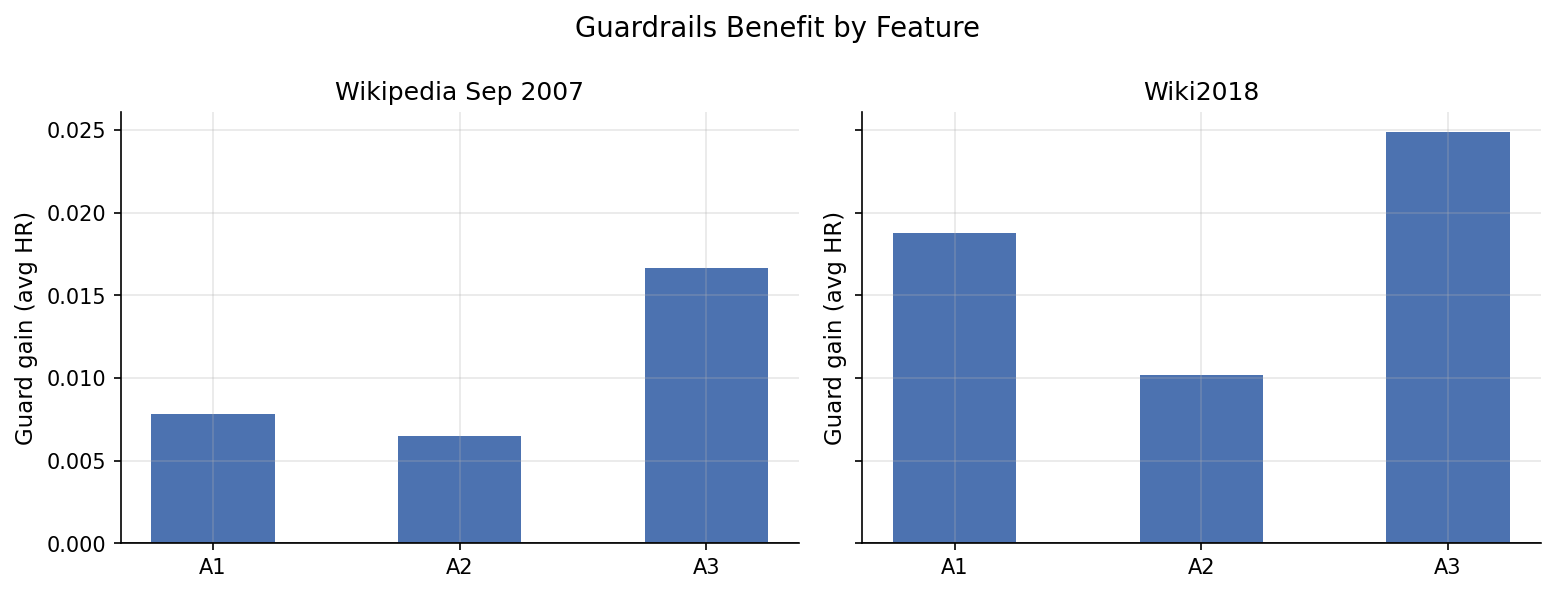

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
for ax, (ds, ds_label) in zip(axes, DATASETS.items()):
    s = guard_delta[guard_delta["dataset"] == ds].set_index("feature").loc[FEATURES]
    ax.bar(np.arange(len(FEATURES)), s["avg_hr_gain"], width=0.5, color="#4c72b0")
    ax.axhline(0.0, color="#444", lw=0.8)
    ax.set_xticks(np.arange(len(FEATURES)))
    ax.set_xticklabels(FEATURES)
    ax.set_title(ds_label)
    ax.set_ylabel("Guard gain (avg HR)")
fig.suptitle("Guardrails Benefit by Feature")
fig.tight_layout()

fig_path = OUT_DIR / "guard_gain_bar.png"
fig.savefig(fig_path)
fig
